In [45]:
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification

In [46]:
x, y = make_classification(n_samples=1000, n_features=6)

In [47]:
df = pd.DataFrame(x)
df["target"] = y

In [48]:
df["weightage"] = 1 / df.shape[0]

In [49]:
df

,0,1,2,3,4,5,target,weightage
0,3.025066,-0.760478,-1.208233,1.477581,-1.302439,1.552751,0,0.001
1,-0.982624,0.871403,0.241565,-0.346704,0.551683,0.489854,1,0.001
2,-1.849663,2.141932,-0.351263,0.059094,1.725420,-0.864987,1,0.001
3,-0.245583,-0.514087,1.397077,-1.267029,-1.001412,-1.974437,1,0.001
4,-0.384466,-1.207180,1.298359,-1.198709,-0.810198,0.545096,1,0.001
...,...,...,...,...,...,...,...,...
995,0.889560,-1.094980,1.045523,-0.802495,-1.576938,1.470508,1,0.001
996,-1.551883,0.920873,0.963921,-1.061858,0.374892,0.432184,1,0.001
997,1.322127,-1.460260,-1.563039,1.559722,0.312881,0.046501,0,0.001
998,-1.392549,-0.180511,-1.131525,0.810159,2.038028,-0.166308,0,0.001


In [50]:
dt_classifier = DecisionTreeClassifier(max_depth=1)

In [51]:
fitted_model = dt_classifier.fit(x, y)

In [52]:
import matplotlib.pyplot as plt

In [53]:
from sklearn.tree import plot_tree

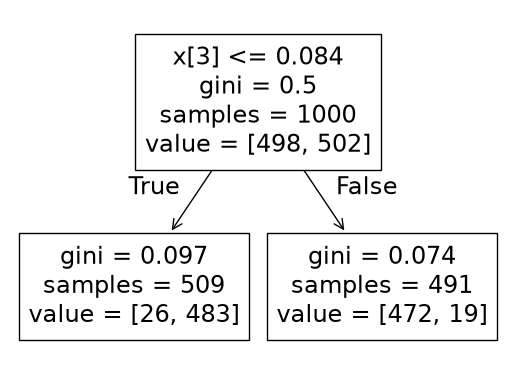

In [54]:
plot_tree(decision_tree=fitted_model)
plt.show()

In [56]:
df["predictions"] = fitted_model.predict(x)

In [58]:
df["diff"] = df["predictions"] - df["target"]

In [65]:
error_rate = df[~(df["diff"] == 0)]["weightage"].sum()

In [71]:
alpha = 0.5 * (np.log((1 - error_rate) / error_rate))

In [72]:
alpha

np.float64(1.5275244253552052)

In [73]:
def update_weights(x: pd.DataFrame):
    if x["diff"] == 0:
        return x["weightage"] * np.exp(-alpha)
    return x["weightage"] * np.exp(alpha)

In [78]:
df["updated_weights"] = df.apply(update_weights, axis=1)

In [83]:
df["updated_weights"] = df["updated_weights"] / df["updated_weights"].sum()

In [89]:
df["range_upper"] = df["updated_weights"].cumsum()
df = df.drop(columns="range")

In [91]:
df["range_lower"] = df["range_upper"] - df["updated_weights"]

In [111]:
def create_new_indices(x: pd.DataFrame, n_samples: int):
    indices = []

    for _ in range(n_samples):
        a = np.random.random()

        for idx, row in x.iterrows():
            if row["range_lower"] <= a < row["range_upper"]:
                indices.append(idx)
                break

    return indices


In [112]:
new_indices = create_new_indices(df, n_samples=len(df))

In [120]:
new_indices = np.unique(new_indices).tolist()

In [124]:
updated_df = df.iloc[new_indices, [0, 1, 2, 3, 4, 5, 6, 7]]

In [128]:
updated_x = updated_df.iloc[:, :-2]
updated_y = updated_df["target"]

In [130]:
updated_dt = DecisionTreeClassifier()

In [131]:
updated_fitted_classifier = updated_dt.fit(updated_x, updated_y)

In [133]:
updated_df["pred"] = updated_fitted_classifier.predict(updated_x)

In [135]:
updated_df["diff"] = updated_df["pred"] - updated_df["target"]

In [137]:
updated_df["diff"].value_counts()

diff
0    441
Name: count, dtype: int64

In [138]:
updated_error_rate = 0

In [140]:
updated_alpha = 0.5 * (
    np.log((1 - updated_error_rate) / (updated_error_rate + 0.0000001))
)

In [142]:
updated_alpha, alpha

(np.float64(8.05904782547916), np.float64(1.5275244253552052))

In [162]:
def predict_adaboost(
    df, fitted_model, updated_fitted_classifier, alpha, updated_alpha, n=100
):
    # Randomly select n rows
    sample = df.sample(n=n, random_state=42)

    predictions = []

    for _, row in sample.iterrows():
        X = row.iloc[:6].values.reshape(1, -1)

        # Predictions from both decision stumps
        ds_1_pred = fitted_model.predict(X)[0]
        ds_2_pred = updated_fitted_classifier.predict(X)[0]

        # Convert 0/1 → -1/+1
        ds_1_pred = 2 * ds_1_pred - 1
        ds_2_pred = 2 * ds_2_pred - 1

        # Weighted vote
        final_score = alpha * ds_1_pred + updated_alpha * ds_2_pred

        # Convert back to 0/1
        final_pred = 1 if final_score >= 0 else 0

        predictions.append(final_pred)

    # Add predictions
    sample = sample.copy()
    sample["pred"] = predictions

    return sample

In [163]:
res = predict_adaboost(
    df=df,
    fitted_model=fitted_model,
    updated_fitted_classifier=updated_fitted_classifier,
    alpha=alpha,
    updated_alpha=updated_alpha,
)

In [165]:
res["res_diff"] = res["pred"] - res["target"]

In [175]:
from sklearn.metrics import (
    accuracy_score,
    mean_absolute_error,
    classification_report,
    confusion_matrix,
)

In [168]:
accuracy_score(res["target"], res["pred"])

0.98

In [ ]:
mean_absolute_error(res["target"], res["pred"])

0.02

In [174]:
import seaborn as sns

print(classification_report(res["target"], res["pred"]))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        49
           1       0.98      0.98      0.98        51

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



[[48  1]
 [ 1 50]]


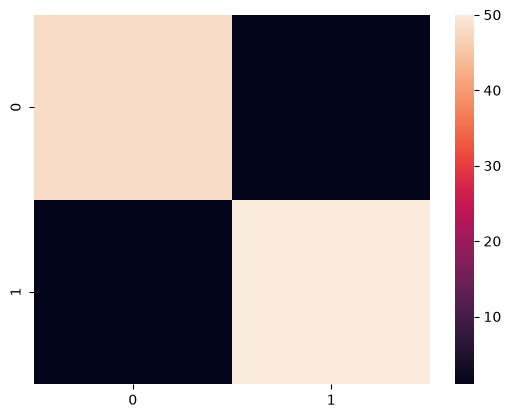

In [182]:
cm = confusion_matrix(res["target"], res["pred"])
sns.heatmap(cm)
print(cm)
plt.show()

In [183]:
from sklearn.ensemble import AdaBoostClassifier

In [198]:
adc = AdaBoostClassifier(n_estimators=100)

In [199]:
sklearn_adc = adc.fit(x, y)

In [200]:
sklearn_adc_pred = sklearn_adc.predict(x)

In [201]:
accuracy_score(df["target"], sklearn_adc_pred)

0.965